# 🚀 Multi-GPU — BERT Fine-tuning avec PyTorch DDP
### TP Deep Learning Distribué — Expérience B : Data Parallelism sur 2 GPU

---
**Objectif :** montrer que `DistributedDataParallel` (DDP) permet (1) d'entraîner plus vite en répartissant les mini-batches sur plusieurs GPU et (2) d'absorber des batch sizes qui provoquent un Out-Of-Memory sur un seul GPU, grâce à la synchronisation des gradients (AllReduce/NCCL).

Ce notebook **lance l'entraînement DDP via `torchrun`** dans un script Python externe (`train_ddp.py`) plutôt que dans le process du notebook lui-même. C'est la méthode robuste recommandée pour le multi-GPU sous Jupyter/Kaggle : elle évite les erreurs de `fork`/`mp.spawn` rencontrées quand on essaie de lancer DDP directement depuis une cellule (contexte CUDA déjà initialisé dans le kernel principal).

**Environnement requis :** Kaggle Notebook avec **GPU T4 x2** activé.

---

## ⚙️ SECTION 1 — Environnement
Installe les dépendances et vérifie le matériel disponible.

In [ ]:
# ───────────────────────────────────────────
# STEP 1 — Install all required libraries
# ───────────────────────────────────────────
!pip install -q "transformers>=4.41.0"
!pip install -q "datasets>=2.20.0"
!pip install -q "pytorch-lightning==2.2.4"
!pip install -q "torchmetrics==1.4.0"
print("✅ All libraries installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.2/802.2 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 868.8/868.8 kB 26.1 MB/s eta 0:00:00
✅ All libraries installed successfully


In [ ]:
# ───────────────────────────────────────────
# STEP 2 — Safe GPU check (does NOT initialize a CUDA context in the
# main notebook kernel — important, because torchrun will spawn its own
# fresh processes later and each must init CUDA itself)
# ───────────────────────────────────────────
import subprocess

result = subprocess.run(
    ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
    capture_output=True, text=True
)
print("GPUs visible to this machine:")
print(result.stdout)

gpu_lines = [l for l in result.stdout.strip().split("\n") if l.strip()]
NUM_GPUS = len(gpu_lines)
print(f"NUM_GPUS = {NUM_GPUS}")

if NUM_GPUS < 2:
    print("\n⚠️  WARNING: Less than 2 GPUs detected.")
    print("   Go to Kaggle Settings → Accelerator → GPU T4 x2")
else:
    print("\n✅ Perfect! 2 GPUs detected. Ready for DDP via torchrun.")

GPUs visible to this machine:
Tesla T4, 15360 MiB
Tesla T4, 15360 MiB

NUM_GPUS = 2

✅ Perfect! 2 GPUs detected. Ready for DDP via torchrun.


## 📦 SECTION 2 — Load and Prepare the IMDb Dataset

In [ ]:
# ───────────────────────────────────────────
# STEP 3 — Download IMDb dataset from HuggingFace
# Size: ~80MB — downloads automatically, no Kaggle account needed
# ───────────────────────────────────────────
from datasets import load_dataset

print("Downloading IMDb dataset...")
raw_dataset = load_dataset("imdb")

print("\n✅ Dataset loaded!")
print(f"   Train samples : {len(raw_dataset['train'])}")
print(f"   Test  samples : {len(raw_dataset['test'])}")
print(f"   Classes       : 0 = Negative, 1 = Positive")

sample = raw_dataset['train'][0]
print(f"\n--- Sample Review (first 200 chars) ---")
print(sample['text'][:200], "...")
print(f"Label: {'POSITIVE ✅' if sample['label'] == 1 else 'NEGATIVE ❌'}")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]


✅ Dataset loaded!
   Train samples : 25000
   Test  samples : 25000
   Classes       : 0 = Negative, 1 = Positive

--- Sample Review (first 200 chars) ---
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev ...
Label: NEGATIVE ❌


In [ ]:
# ───────────────────────────────────────────
# STEP 4 — Tokenize the dataset with BertTokenizer
# What happens: raw text → token IDs that BERT understands
# ───────────────────────────────────────────
from transformers import BertTokenizer

print("Loading BERT tokenizer...")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",   # pad short reviews to 128 tokens
        truncation=True,        # cut long reviews at 128 tokens
        max_length=128          # 128 keeps VRAM usage manageable
    )

print("Tokenizing dataset (this takes ~2 minutes)...")
tokenized = raw_dataset.map(tokenize_function, batched=True)
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print("\n✅ Tokenization complete!")
print("--- Before tokenization ---")
print(f"Raw text: '{raw_dataset['train'][0]['text'][:60]}...'")
print("\n--- After tokenization ---")
print(f"input_ids shape : {tokenized['train'][0]['input_ids'].shape}")
print(f"First 10 tokens : {tokenized['train'][0]['input_ids'][:10]}")
print(f"Decoded back     : {tokenizer.decode(tokenized['train'][0]['input_ids'][:10])}")

Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing dataset (this takes ~2 minutes)...


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]


✅ Tokenization complete!
--- Before tokenization ---
Raw text: 'I rented I AM CURIOUS-YELLOW from my video store because of ...'

--- After tokenization ---
input_ids shape : torch.Size([128])
First 10 tokens : tensor([  101,  1045, 12524,  1045,  2572,  8025,  1011,  3756,  2013,  2026])
Decoded back     : [CLS] i rented i am curious - yellow from my


## 🧠 SECTION 3 — Define the BERT Model with PyTorch Lightning

In [ ]:
# ───────────────────────────────────────────
# STEP 6 — Define the Lightning Model
# LightningModule wraps BERT and handles train/val logic.
# This EXACT class is reused unchanged in train_ddp.py for Experiment B,
# so the only variable between experiments is the parallelization strategy.
# ───────────────────────────────────────────
import pytorch_lightning as pl
import torch.nn as nn
from transformers import BertForSequenceClassification
from torch.optim import AdamW
from torchmetrics.classification import BinaryAccuracy

class BERTSentimentClassifier(pl.LightningModule):
    """
    BERT fine-tuned for binary sentiment classification.
    Architecture:
        Input text → BertTokenizer → BERT (110M params) → [CLS] vector → Linear(768→2) → Softmax
    """

    def __init__(self, learning_rate=2e-5):
        super().__init__()
        self.save_hyperparameters()

        self.model = BertForSequenceClassification.from_pretrained(
            "bert-base-uncased",
            num_labels=2
        )

        self.train_acc = BinaryAccuracy()
        self.val_acc   = BinaryAccuracy()

    def forward(self, input_ids, attention_mask, labels=None):
        return self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

    def training_step(self, batch, batch_idx):
        """
        One training step = one mini-batch.
        Under DDP each GPU runs this INDEPENDENTLY on its own shard of data,
        then gradients are synchronized across GPUs via AllReduce (NCCL)
        before the optimizer step
        """
        outputs = self(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["label"]
        )
        loss   = outputs.loss
        logits = outputs.logits
        preds  = torch.argmax(logits, dim=1)

        self.train_acc(preds, batch["label"])
        self.log("train_loss", loss,           prog_bar=True, sync_dist=True)
        self.log("train_acc",  self.train_acc, prog_bar=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        """sync_dist=True averages metrics across all GPUs (the reduction step)."""
        outputs = self(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["label"]
        )
        loss   = outputs.loss
        logits = outputs.logits
        preds  = torch.argmax(logits, dim=1)

        self.val_acc(preds, batch["label"])
        self.log("val_loss", loss,         prog_bar=True, sync_dist=True)
        self.log("val_acc",  self.val_acc, prog_bar=True, sync_dist=True)

    def configure_optimizers(self):
        return AdamW(self.parameters(), lr=self.hparams.learning_rate, weight_decay=0.01)


print("✅ BERTSentimentClassifier defined")
print("   Parameters: ~110 million (bert-base-uncased)")
print("   Input : input_ids + attention_mask (shape: [batch, 128])")
print("   Output: 2 logits → Positive or Negative")

/usr/local/lib/python3.12/dist-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


✅ BERTSentimentClassifier defined
   Parameters: ~110 million (bert-base-uncased)
   Input : input_ids + attention_mask (shape: [batch, 128])
   Output: 2 logits → Positive or Negative


## 📝 SECTION 4 — Write the DDP training script
We cannot reliably launch `DistributedDataParallel` **from inside** a running notebook kernel: the kernel's Python process has already initialized a CUDA context on GPU 0, and PyTorch's process-spawning machinery (`fork`/`mp.spawn`/`ddp_spawn`) then deadlocks or errors (`Can't get attribute ... on <module '__main__'>`), because the child processes try to re-import a `__main__` that only exists inside the Jupyter kernel.

**The robust fix:** write the training code to a standalone `.py` file and launch it with `torchrun`, exactly like you would in production. `torchrun` starts one **completely independent OS process per GPU**, each with its own clean CUDA context — no fork, no spawn tricks needed.

In [ ]:
# ───────────────────────────────────────────
# STEP 6 — Generate train_ddp.py
# One process per GPU is spawned by torchrun; torchrun sets the
# environment variables RANK / LOCAL_RANK / WORLD_SIZE for each of them.
# ───────────────────────────────────────────
train_ddp_source = r'''
"""
train_ddp.py — Experiment B: BERT fine-tuning with PyTorch Lightning DDP.
Launched with:  torchrun --standalone --nproc_per_node=<N_GPUS> train_ddp.py
One process is spawned per GPU. PyTorch Lightning detects the torchrun
environment variables automatically (strategy="ddp" + devices=N_GPUS).
"""
import os, json, time, argparse
import torch
import torch.nn as nn
import pytorch_lightning as pl
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from torchmetrics.classification import BinaryAccuracy
from transformers import BertTokenizer, BertForSequenceClassification
from datasets import load_dataset

torch.set_float32_matmul_precision('medium')


def build_arg_parser():
    p = argparse.ArgumentParser()
    p.add_argument("--batch-size-per-gpu", type=int, default=128)
    p.add_argument("--epochs", type=int, default=2)
    p.add_argument("--train-size", type=int, default=20000)
    p.add_argument("--val-size", type=int, default=5000)
    p.add_argument("--num-gpus", type=int, default=2)
    p.add_argument("--output-dir", type=str, default="/kaggle/working")
    # OFF by default: trainer.save_checkpoint() is a collective op under DDP —
    # calling it from rank 0 only deadlocks waiting on a barrier the other
    # rank never reaches. Not needed for the TP's speed/accuracy comparison.
    p.add_argument("--save-checkpoint", action="store_true", default=False)
    return p


class BERTSentimentClassifier(pl.LightningModule):
    """Identical architecture and logic to the single-GPU notebook —
    only the Trainer configuration below changes between experiments."""

    def __init__(self, learning_rate=2e-5):
        super().__init__()
        self.save_hyperparameters()
        self.model = BertForSequenceClassification.from_pretrained(
            "bert-base-uncased", num_labels=2
        )
        self.train_acc = BinaryAccuracy()
        self.val_acc   = BinaryAccuracy()

    def forward(self, input_ids, attention_mask, labels=None):
        return self.model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

    def training_step(self, batch, batch_idx):
        outputs = self(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"], labels=batch["label"])
        preds = torch.argmax(outputs.logits, dim=1)
        self.train_acc(preds, batch["label"])
        self.log("train_loss", outputs.loss, prog_bar=True, sync_dist=True)
        self.log("train_acc", self.train_acc, prog_bar=True, sync_dist=True)
        return outputs.loss

    def validation_step(self, batch, batch_idx):
        outputs = self(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"], labels=batch["label"])
        preds = torch.argmax(outputs.logits, dim=1)
        self.val_acc(preds, batch["label"])
        self.log("val_loss", outputs.loss, prog_bar=True, sync_dist=True)
        self.log("val_acc", self.val_acc, prog_bar=True, sync_dist=True)

    def configure_optimizers(self):
        return AdamW(self.parameters(), lr=self.hparams.learning_rate, weight_decay=0.01)


class EpochTimer(pl.Callback):
    """Prints the wall-clock time of each epoch AS IT HAPPENS.
    trainer.is_global_zero == True only in the rank-0 process, so with
    2 GPUs (2 independent OS processes under torchrun) this still prints
    exactly ONE line per epoch instead of one per GPU."""
    def on_train_epoch_start(self, trainer, pl_module):
        self._t0 = time.time()

    def on_train_epoch_end(self, trainer, pl_module):
        dt = time.time() - self._t0
        if trainer.is_global_zero:
            print(f"  ⏱️  Epoch {trainer.current_epoch + 1}/{trainer.max_epochs} "
                  f"terminée en {dt:.1f}s", flush=True)


def main():
    args = build_arg_parser().parse_args()
    is_main_process = int(os.environ.get("RANK", "0")) == 0

    raw_dataset = load_dataset("imdb")
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

    def tokenize_function(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

    tokenized = raw_dataset.map(tokenize_function, batched=True)
    tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

    # Same seed as the single-GPU notebook -> same train/val split -> fair comparison
    g = torch.Generator().manual_seed(42)
    train_subset, _ = random_split(tokenized["train"], [args.train_size, len(tokenized["train"]) - args.train_size], generator=g)
    val_subset, _   = random_split(tokenized["test"],  [args.val_size,   len(tokenized["test"])  - args.val_size], generator=g)

    # num_workers=0: DataLoader worker subprocesses interact poorly with
    # torchrun-spawned processes; each of the N torchrun processes already
    # gets its own share of the DistributedSampler shard.
    train_loader = DataLoader(train_subset, batch_size=args.batch_size_per_gpu, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_subset,   batch_size=args.batch_size_per_gpu, shuffle=False, num_workers=0)

    model = BERTSentimentClassifier(learning_rate=2e-5)

    trainer = pl.Trainer(
        accelerator="gpu",
        devices=args.num_gpus,
        num_nodes=1,
        strategy="ddp",              # DistributedSampler + gradient AllReduce (NCCL)
        max_epochs=args.epochs,
        precision="16-mixed",
        enable_progress_bar=False,
        callbacks=[EpochTimer()],
        log_every_n_steps=50,
        enable_checkpointing=False,
    )

    if is_main_process:
        print("=" * 55)
        print("EXPERIMENT B: DDP Training")
        print("=" * 55)
        print(f"Config: {args.num_gpus} GPU(s) | Batch/GPU={args.batch_size_per_gpu} "
              f"| Global batch={args.batch_size_per_gpu * args.num_gpus} | Epochs={args.epochs}")

    start = time.time()
    trainer.fit(model, train_loader, val_loader)
    elapsed = time.time() - start

    if is_main_process:
        print(f"\n✅ Training loop finished in {elapsed:.1f}s. Saving results (rank 0 only)...", flush=True)

        metrics = trainer.callback_metrics
        summary = {
            "experiment": "B - DDP multi-GPU",
            "num_gpus": args.num_gpus,
            "batch_size_per_gpu": args.batch_size_per_gpu,
            "global_batch_size": args.batch_size_per_gpu * args.num_gpus,
            "epochs": args.epochs,
            "train_size": args.train_size,
            "val_size": args.val_size,
            "time_seconds": elapsed,
            "train_loss": float(metrics.get("train_loss", float("nan"))),
            "val_acc": float(metrics.get("val_acc", float("nan"))),
        }
        os.makedirs(args.output_dir, exist_ok=True)
        with open(os.path.join(args.output_dir, "results_multi_gpu.json"), "w") as f:
            json.dump(summary, f, indent=2)
        print("📄 results_multi_gpu.json written.", flush=True)

    # ── Checkpoint save (optional, OFF by default) ─────────────────────────
    # IMPORTANT: this is a collective operation under DDP — every rank must
    # call it together, or the ranks that skip it leave the ones that call it
    # waiting forever on a barrier. That mismatch (rank 0 only) is exactly
    # what caused the earlier hang, so this call is now OUTSIDE the
    # `if is_main_process:` block and runs on every process when enabled.
    if args.save_checkpoint:
        ckpt_path = os.path.join(args.output_dir, "bert_ddp_checkpoint.ckpt")
        if is_main_process:
            print(f"💾 Saving checkpoint to {ckpt_path} (all ranks participating)...", flush=True)
        trainer.save_checkpoint(ckpt_path)
        if is_main_process:
            print("✅ Checkpoint saved successfully.", flush=True)
    elif is_main_process:
        print("⏭️  Skipping checkpoint save (pass --save-checkpoint to enable it). "
              "Not needed for the speed/accuracy comparison.", flush=True)

    if is_main_process:
        print("\n" + "=" * 55)
        print("EXPERIMENT B — RESULTS")
        print("=" * 55)
        print(json.dumps(summary, indent=2))
        print("\n🏁 train_ddp.py finished — safe to move on to STEP 8.", flush=True)


if __name__ == "__main__":
    main()
'''

with open("train_ddp.py", "w") as f:
    f.write(train_ddp_source)

print("✅ train_ddp.py written to disk")
print(f"   {len(train_ddp_source.splitlines())} lines")

✅ train_ddp.py written to disk
   183 lines


In [ ]:
# ───────────────────────────────────────────
# STEP 7 — Launch DDP training with torchrun
# --nproc_per_node = number of GPUs = number of processes torchrun spawns
# Each process gets RANK/LOCAL_RANK/WORLD_SIZE env vars automatically.
# ───────────────────────────────────────────
import subprocess, sys, os

N_GPUS = NUM_GPUS if NUM_GPUS >= 2 else 1   # falls back to 1 process if only 1 GPU is available
OUTPUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."

cmd = [
    sys.executable, "-m", "torch.distributed.run",
    "--standalone",
    f"--nproc_per_node={N_GPUS}",
    "train_ddp.py",
    "--batch-size-per-gpu", "128",
    "--epochs", "2",
    "--train-size", "20000",   # ← must match single-gpu-experiment.ipynb for a fair comparison
    "--val-size", "5000",
    "--num-gpus", str(N_GPUS),
    "--output-dir", OUTPUT_DIR,
]

print("Launching:", " ".join(cmd))
print("(this streams live output; training with 2×T4 takes a few minutes)\n")

process = subprocess.run(cmd, capture_output=False, text=True)

if process.returncode != 0:
    print(f"\n⚠️  torchrun exited with code {process.returncode} — check the log above for the error.")
else:
    print("\n✅ DDP training finished successfully.")

Launching: /usr/bin/python3 -m torch.distributed.run --standalone --nproc_per_node=2 train_ddp.py --batch-size-per-gpu 128 --epochs 2 --train-size 20000 --val-size 5000 --num-gpus 2 --output-dir /kaggle/working
(this streams live output; training with 2×T4 takes a few minutes)




*****************************************
Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
*****************************************
[W704 11:03:34.137079138 socket.cpp:207] [c10d] The hostname of the client socket cannot be retrieved. err=-3
/usr/local/lib/python3.12/dist-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/usr/local/lib/python3.12/dist-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setupt

EXPERIMENT B: DDP Training
Config: 2 GPU(s) | Batch/GPU=128 | Global batch=256 | Epochs=2
  ⏱️  Epoch 1/2 terminée en 109.5s
  ⏱️  Epoch 2/2 terminée en 113.4s

✅ Training loop finished in 244.3s. Saving results (rank 0 only)...
📄 results_multi_gpu.json written.
⏭️  Skipping checkpoint save (pass --save-checkpoint to enable it). Not needed for the speed/accuracy comparison.

EXPERIMENT B — RESULTS
{
  "experiment": "B - DDP multi-GPU",
  "num_gpus": 2,
  "batch_size_per_gpu": 128,
  "global_batch_size": 256,
  "epochs": 2,
  "train_size": 20000,
  "val_size": 5000,
  "time_seconds": 244.33999848365784,
  "train_loss": 0.18328356742858887,
  "val_acc": 0.8709999918937683
}

🏁 train_ddp.py finished — safe to move on to STEP 8.

✅ DDP training finished successfully.


## 📊 SECTION 5 — Final Comparison: 1 GPU vs. 2 GPUs (DDP)

In [ ]:
# ───────────────────────────────────────────
# STEP 8 — Load both result files and build the comparison table
# ───────────────────────────────────────────
import json, os
import pandas as pd


# adapt this path to your project directory
single_path = "/kaggle/input/datasets/abenjelloun/results-single-gpu/results_single_gpu.json"

multi_path  = os.path.join(OUTPUT_DIR, "results_multi_gpu.json")

if os.path.exists(single_path):
    with open(single_path) as f:
        results_single = json.load(f)
    print("✅ Loaded results_single_gpu.json (produced by single-gpu-experiment.ipynb)")
else:
    print("⚠️  results_single_gpu.json not found — run single-gpu-experiment.ipynb first "
          "(in the same /kaggle/working session) to get a REAL baseline.")
    print("   Falling back to a placeholder value so the notebook can still run end-to-end.")
    results_single = {"time_seconds": float("nan"), "val_acc": float("nan"), "batch_size": 32}

with open(multi_path) as f:
    results_multi = json.load(f)

time_single = results_single["time_seconds"]
time_ddp    = results_multi["time_seconds"]
speedup     = time_single / time_ddp if time_ddp and time_single == time_single else float("nan")

results_table = pd.DataFrame({
    "Experiment"    : ["A — Single GPU", "B — DDP (N GPUs)"],
    "GPUs Used"     : [results_single.get("num_gpus", 1), results_multi["num_gpus"]],
    "Batch Size"    : [results_single.get("batch_size", 32),
                        f"{results_multi['batch_size_per_gpu']}×{results_multi['num_gpus']} "
                        f"= {results_multi['global_batch_size']} total"],
    "Training Time (s)": [f"{time_single:.1f}", f"{time_ddp:.1f}"],
    "Val Accuracy"  : [f"{results_single.get('val_acc', float('nan')):.3f}",
                        f"{results_multi['val_acc']:.3f}"],
})

print("\n" + "=" * 70)
print("FINAL COMPARISON — Distributed Training Demonstration")
print("=" * 70)
print(results_table.to_string(index=False))
print("=" * 70)
print(f"\n📈 Speedup factor      : {speedup:.2f}x faster with DDP" if speedup == speedup else "\n📈 Speedup: run single-gpu-experiment.ipynb first to compute this")
if speedup == speedup:
    print(f"⏱️  Time saved          : {(time_single - time_ddp):.0f} seconds")
print(f"🎯 Accuracy difference : both experiments should reach similar accuracy")
print(f"   → proves the gradient AllReduce (sync_dist) is working correctly")

✅ Loaded results_single_gpu.json (produced by single-gpu-experiment.ipynb)

FINAL COMPARISON — Distributed Training Demonstration
      Experiment  GPUs Used        Batch Size Training Time (s) Val Accuracy
  A — Single GPU          1                32             340.5        0.872
B — DDP (N GPUs)          2 128×2 = 256 total             244.3        0.871

📈 Speedup factor      : 1.39x faster with DDP
⏱️  Time saved          : 96 seconds
🎯 Accuracy difference : both experiments should reach similar accuracy
   → proves the gradient AllReduce (sync_dist) is working correctly


## 🔍 SECTION 6 — Inference Demo (DDP-trained model)

In [ ]:
# ───────────────────────────────────────────
# STEP 9 — Load the checkpoint saved by train_ddp.py and run inference
# ───────────────────────────────────────────
import torch
import torch.nn.functional as F
from transformers import BertTokenizer

# The model class needs to be importable in this kernel to load the checkpoint.
# We exec the script's class definition (not main()) to reuse the exact same architecture.
import importlib.util
spec = importlib.util.spec_from_file_location("train_ddp", "train_ddp.py")
train_ddp_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(train_ddp_module)

checkpoint_path = os.path.join(OUTPUT_DIR, "bert_ddp_checkpoint.ckpt")
inference_model = train_ddp_module.BERTSentimentClassifier.load_from_checkpoint(checkpoint_path)
inference_model = inference_model.to("cuda:0").eval()

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def predict_sentiment(text, model, tokenizer, device="cuda:0"):
    encoding = tokenizer(text, return_tensors="pt", padding="max_length", truncation=True, max_length=128)
    input_ids      = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = F.softmax(outputs.logits, dim=1)
        pred    = torch.argmax(probs, dim=1).item()
        conf    = probs[0][pred].item()
    label = "POSITIVE ✅" if pred == 1 else "NEGATIVE ❌"
    return label, conf

custom_reviews = [
    "This movie was absolutely incredible. The acting was phenomenal and I was on the edge of my seat the entire time.",
    "Terrible film. Boring plot, bad acting, and a complete waste of 2 hours. I almost fell asleep.",
    "It was okay. Some parts were good but overall the story felt a bit weak and predictable."
]

print("=" * 60)
print("INFERENCE DEMO — Sentiment Predictions (DDP-trained model)")
print("=" * 60)

for i, review in enumerate(custom_reviews, 1):
    label, confidence = predict_sentiment(review, inference_model, tokenizer)
    print(f"\nReview {i}: \"{review[:70]}...\"")
    print(f"  Prediction  : {label}")
    print(f"  Confidence  : {confidence*100:.1f}%")

print("\n" + "=" * 60)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


INFERENCE DEMO — Sentiment Predictions (DDP-trained model)

Review 1: "This movie was absolutely incredible. The acting was phenomenal and I ..."
  Prediction  : POSITIVE ✅
  Confidence  : 97.1%

Review 2: "Terrible film. Boring plot, bad acting, and a complete waste of 2 hour..."
  Prediction  : NEGATIVE ❌
  Confidence  : 98.5%

Review 3: "It was okay. Some parts were good but overall the story felt a bit wea..."
  Prediction  : NEGATIVE ❌
  Confidence  : 93.6%



## 📈 SECTION 7 — Visualize the Comparison

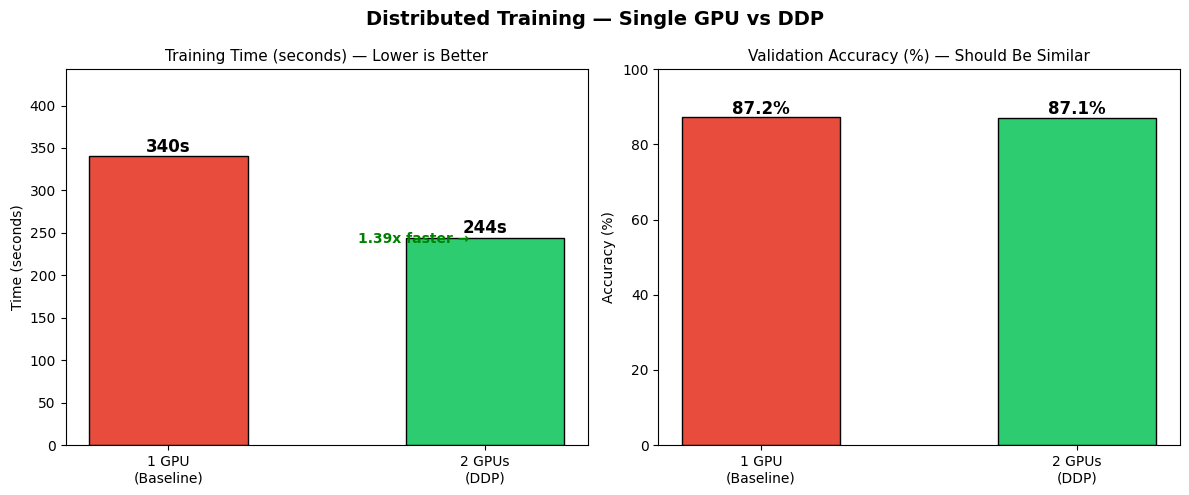

✅ Chart saved to /kaggle/working/comparison_chart.png


In [ ]:
# ───────────────────────────────────────────
# STEP 10 — Plot the comparison bar chart
# ───────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distributed Training — Single GPU vs DDP", fontsize=14, fontweight="bold")

ax1 = axes[0]
bars = ax1.bar(
    ["1 GPU\n(Baseline)", f"{results_multi['num_gpus']} GPUs\n(DDP)"],
    [time_single, time_ddp],
    color=["#e74c3c", "#2ecc71"], width=0.5, edgecolor="black"
)
ax1.set_title("Training Time (seconds) — Lower is Better", fontsize=11)
ax1.set_ylabel("Time (seconds)")
if time_single == time_single:
    ax1.set_ylim(0, time_single * 1.3)
    for bar, val in zip(bars, [time_single, time_ddp]):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f"{val:.0f}s",
                  ha="center", fontweight="bold", fontsize=12)
    ax1.annotate(f"{speedup:.2f}x faster →", xy=(1, time_ddp), xytext=(0.6, time_single * 0.7),
                 fontsize=10, color="green", fontweight="bold")

ax2 = axes[1]
acc_single = float(results_single.get("val_acc", float("nan")))
acc_ddp    = float(results_multi["val_acc"])
bars2 = ax2.bar(
    ["1 GPU\n(Baseline)", f"{results_multi['num_gpus']} GPUs\n(DDP)"],
    [acc_single * 100, acc_ddp * 100],
    color=["#e74c3c", "#2ecc71"], width=0.5, edgecolor="black"
)
ax2.set_title("Validation Accuracy (%) — Should Be Similar", fontsize=11)
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim(0, 100)
for bar, val in zip(bars2, [acc_single * 100, acc_ddp * 100]):
    if val == val:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{val:.1f}%",
                  ha="center", fontweight="bold", fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_chart.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Chart saved to {os.path.join(OUTPUT_DIR, 'comparison_chart.png')}")